# TQC — EV2Gym V2G Profit Maximization Benchmark

**Algorithm:** Truncated Quantile Critics (Kuznetsov et al. 2020)
**Type:** off-policy · stochastic actor · distributional critic · entropy regularisation
**Library:** `sb3_contrib`
**Scenario:** Workplace · 10 charging stations · 85 steps × 15 min
**Reference:** Orfanoudakis et al. 2025 (arXiv:2404.01849), Table VII
**Paper result (no HPO):** profit = 1.9 ± 21.6 € · sat = 72 ± 24 % · overload = 35 ± 56 kWh

## Protocol

A two-phase Optuna HPO framework benchmarks TQC on the V2G profit maximization
task using EV2Gym Model 1 (workplace scenario, 10 charging stations, 85 steps × 15 min).

1. **Phase 1 — Algorithm HPO:** 30 TPE trials × 100k steps optimize the algorithm's
   internal hyperparameters with the standard environment configuration.
2. **Phase 2 — Joint HPO (diagnostic):** 30 TPE trials × 100k steps jointly optimize
   algorithm HPs and three environment parameters (`spawn_multiplier`,
   `discharge_price_factor`, `transformer.max_power`). Phase 2 identifies
   environment-induced performance ceilings and should not be interpreted as
   achievable operational performance.
3. **Final training:** 1M steps with the Model-2 proxy reward (`PowerTrackingErrorMin`,
   dense signal). 30 parallel environments via SubprocVecEnv.
4. **Evaluation:** Model-1 sparse reward (`profit_maximization`). 5 seeds × 20 episodes
   = 100 episodes per phase. Seeds `[42, 123, 999, 7, 89]` (Henderson et al. 2018).
5. **Statistical testing:** Bootstrap 95% CIs + Wilcoxon signed-rank tests
   (Agarwal et al. 2021).
6. **HPO budget sensitivity:** Best-so-far curves for 30/60/100 trials to validate
   the 30-trial budget.
7. **Proxy reward ablation:** Direct comparison between the proxy-trained agent and
   an agent trained on Model-1 reward, isolating the effect of reward substitution.

## Reward design

Training uses the Model-2 dense proxy reward (§IV-C, EV2Gym paper): the dense signal
accelerates credit assignment during learning. Evaluation always uses the Model-1 sparse
reward so results are directly comparable to Table VII of the EV2Gym paper.
VecNormalize observation statistics are frozen (`training=False`) before evaluation.

## How to run

Set `MODE = 'PROD'` in Cell 1 for the full publishable run (~8–12 h on a GPU server
with N_ENVS = 30). Use `MODE = 'TEST'` to verify correctness in minutes.


In [1]:
# ═══════════════════════════════════════════════════════════════════════════
#  MODE CONFIGURATION
#  Set MODE = 'TEST' to verify correctness end-to-end (minutes)
#  Set MODE = 'PROD' for the full publishable run (hours)
# ═══════════════════════════════════════════════════════════════════════════

MODE = 'PROD'   # <-- change to 'PROD' for production

if MODE == 'TEST':
    # ── Optuna ──────────────────────────────────────────────────────────────
    PHASE1_N_TRIALS  = 3          # PROD: 30
    PHASE2_N_TRIALS  = 3          # PROD: 30
    PHASE1_TIMESTEPS = 5_000      # PROD: 100_000
    PHASE2_TIMESTEPS = 5_000      # PROD: 100_000
    PHASE1_EVAL_EPS  = 2          # PROD: 8
    PHASE2_EVAL_EPS  = 2          # PROD: 8
    # ── Final training ──────────────────────────────────────────────────
    TOTAL_TIMESTEPS  = 10_000     # PROD: 1_000_000
    N_ENVS           = 4          # PROD: 30
    # ── Evaluation ──────────────────────────────────────────────────────────
    EVAL_SEEDS        = [42, 123]                  # PROD: [42, 123, 999, 7, 89]
    EPISODES_PER_SEED = 5                          # PROD: 20
    # ──  Bootstrap ──────────────────────────────────────────────────
    N_BOOTSTRAP      = 100        # PROD: 10_000
    # ──  Sensitivity ────────────────────────────────────────────────
    SENSITIVITY_TRIALS = [3, 5]   # PROD: [30, 60, 100]
    SENSITIVITY_STEPS  = 2_000    # PROD: 100_000
    # ──  Ablation reward ──────────────────────────────────────────────
    ABLATION_TIMESTEPS = 5_000    # PROD: 1_000_000
    ABLATION_N_ENVS    = 2        # PROD: 4
else:  # PROD
    # ── Optuna ──────────────────────────────────────────────────────────────
    PHASE1_N_TRIALS  = 30
    PHASE2_N_TRIALS  = 30
    PHASE1_TIMESTEPS = 100_000
    PHASE2_TIMESTEPS = 100_000
    PHASE1_EVAL_EPS  = 8
    PHASE2_EVAL_EPS  = 8
    # ── Final training ──────────────────────────────────────────────────
    TOTAL_TIMESTEPS  = 1_000_000
    N_ENVS           = 30
    # ── Evaluation ──────────────────────────────────────────────────────────
    EVAL_SEEDS        = [42, 123, 999, 7, 89]
    EPISODES_PER_SEED = 20
    # ──  Bootstrap ──────────────────────────────────────────────────
    N_BOOTSTRAP      = 10_000
    # ──  Sensitivity ────────────────────────────────────────────────
    SENSITIVITY_TRIALS = [30, 60, 100]
    SENSITIVITY_STEPS  = 100_000
    # ──  Ablation reward ──────────────────────────────────────────────
    ABLATION_TIMESTEPS = 1_000_000
    ABLATION_N_ENVS    = 4

EVAL_EPISODES = len(EVAL_SEEDS) * EPISODES_PER_SEED
print(f'Mode: {MODE}')
print(f'Optuna Phase 1/2: {PHASE1_N_TRIALS} trials × {PHASE1_TIMESTEPS:,} steps')
print(f'Training: {TOTAL_TIMESTEPS:,} steps | {N_ENVS} envs')
print(f'Evaluation: {len(EVAL_SEEDS)} seeds x {EPISODES_PER_SEED} eps = {EVAL_EPISODES} eps/phase')
print(f'Bootstrap: {N_BOOTSTRAP} iteraciones')
print(f'Sensitivity: {SENSITIVITY_TRIALS} trials x {SENSITIVITY_STEPS:,} steps')
print(f'Ablation: {ABLATION_TIMESTEPS:,} steps')


Mode: PROD
Optuna Phase 1/2: 30 trials × 100,000 steps
Training: 1,000,000 steps | 30 envs
Evaluation: 5 seeds x 20 eps = 100 eps/phase
Bootstrap: 10000 iteraciones
Sensitivity: [30, 60, 100] trials x 100,000 steps
Ablation: 1,000,000 steps


In [2]:
import copy, json, time, warnings, random
from pathlib import Path
from typing import Any, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yaml
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

import torch
import sys
# START_METHOD: 'fork' on Linux VMs, 'spawn' on Windows/macOS
START_METHOD = "fork" if sys.platform.startswith("linux") else "spawn"

import gymnasium as gym
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize, SubprocVecEnv
from sb3_contrib import TQC

from ev2gym.rl_agent.reward import profit_maximization
from ev2gym.rl_agent.state  import V2G_profit_max

RESULTS_ROOT = Path("results_tqc_model1")
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
print("Results in:", RESULTS_ROOT)

# ── Reproducibility log ──────────────────────────────────────────────────────
REPRO_LOG = {
    "algorithm": "TQC",
    "model": "Model1_V2G_Profit_Maximization",
    "training_reward": "Model-2 proxy (dense): r_t = -(P_set_{t-1} - P_tot_{t-1})^2",
    "evaluation_reward": "Model-1 (sparse): r_t = c_{t-1} - 100*eps_ov - 100*exp(-10*eps_usr)",
    "proxy_reward_note": "Agents are NOT trained on the satisfaction term directly. This may contribute to satisfaction collapse in aggressive policies.",
    "vecnorm_freeze": "VecNormalize stats frozen after training (training=False, norm_reward=False) before ALL evaluation episodes.",
    "eval_seeds": [42, 123, 999, 7, 89],
    "episodes_per_seed": 20,
    "total_eval_episodes": 100,  # 5 seeds x 20 eps
    "training_timesteps": 1_000_000,
    "n_parallel_envs": 30,
    "optuna_trials_per_phase": 30,
    "optuna_trial_timesteps": 100_000,
    "optuna_eval_episodes_per_trial": 8,
    "optuna_asymmetry_note": "F2 searches same 30 trials as F1 but across 3 additional YAML dimensions (spawn_multiplier, discharge_price_factor, transformer_max_power). F2 HPs may be less thoroughly tuned per dimension.",
    "mpc_horizon_note": "EV2Gym paper MPC uses prediction+control horizon of 25 steps (Table VII footnote). Our reproduced variant horizon could not be unambiguously matched — treated as a distinct controller.",
    "single_scenario_note": "All results are from the workplace scenario only. Conclusions about algorithm rankings cannot be generalized without additional scenarios.",
    "statistical_note": "High std relative to mean in Phase 2 (e.g. PPO F2: 77±58 EUR). Pairwise differences may not be statistically significant without formal testing (bootstrap CIs / Wilcoxon)."
}
print("Reproducibility log initialized.")


Results in: results_tqc_model1
Reproducibility log initialized.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# YAML Model 1 embebido
#
#  MPC HORIZON NOTE:
#  The EV2Gym paper (Table VII) uses the rolling-horizon MPC controller
#  (V2GProfitMaxOracle) with a prediction+control horizon of 25 steps
#  (stated in §V-B of the EV2Gym paper). Our reproduced MPC variant could
#  not unambiguously match that configuration, so it is treated as a
#  distinct controller ("reproduced variant") — not a faithful replication.
#  This explains the sign reversal in profit (+17.8 paper vs -7.6 ours).
#  See reproducibility_log.json for the full disclaimer.
#
#  [not used in Model 1]:
#    simulate_grid / network_info / pf_solver  → Modelo 3 (flujo de potencia por buses)
#    power_setpoint_enabled                    → Model 2 (Power Setpoint Tracking)
#
#  charging_network_topology debe ser el STRING "None" (no Python None):
#  EV2Gym hace open() directo sobre ese valor. Con None → TypeError.
#  With the string "None" → FileNotFoundError → generates a random network topology.
# ─────────────────────────────────────────────────────────────────────────────

MODEL1_YAML_STR = """
timescale: 15
simulation_length: 85

year: 2022
month: 1
day: 17
random_day: true
random_hour: false
hour: 7
minute: 0
simulation_days: weekdays

scenario: workplace
spawn_multiplier: 3

discharge_price_factor: 1

v2g_enabled: true
number_of_charging_stations: 10
number_of_transformers: 1
number_of_ports_per_cs: 1
charging_network_topology: None

simulate_grid: false
power_setpoint_enabled: false

inflexible_loads:
  include: false
  inflexible_loads_capacity_multiplier_mean: 1
  forecast_mean: 30
  forecast_std: 5

solar_power:
  include: false
  solar_power_capacity_multiplier_mean: 1
  forecast_mean: 20
  forecast_std: 5

demand_response:
  include: false
  events_per_day: 1
  event_capacity_percentage_mean: 35
  event_capacity_percentage_std: 5
  event_length_minutes_min: 60
  event_length_minutes_max: 60
  event_start_hour_mean: 12
  event_start_hour_std: 2
  notification_of_event_minutes: 60

heterogeneous_ev_specs: false
ev_specs_file: ./ev2gym/data/ev_specs_v2g_enabled2024.json

transformer:
  max_power: 200

charging_station:
  min_charge_current: 0
  max_charge_current: 32
  min_discharge_current: 0
  max_discharge_current: -32
  voltage: 400
  phases: 3

ev:
  battery_capacity: 70
  max_ac_charge_power: 22
  min_ac_charge_power: 0
  max_dc_charge_power: 50
  max_discharge_power: -22
  min_discharge_power: 0
  ev_phases: 3
  charge_efficiency: 1
  discharge_efficiency: 1
  transition_soc: 1
  min_battery_capacity: 15
  min_time_of_stay: 200
  min_emergency_battery_capacity: 15
  desired_capacity: 1
  transition_soc_multiplier: 50

tr_seed: -1
"""

def save_cfg(cfg: dict, path) -> str:
    """Guarda cfg limpiando Nones. charging_network_topology se fuerza a string 'None'."""
    out = {}
    for k, v in cfg.items():
        if k == "charging_network_topology":
            out[k] = "None" if (v is None or str(v) == "None") else str(v)
        elif isinstance(v, dict):
            out[k] = v  # sub-dicts (transformer, ev, etc.) se pasan completos
        elif v is None:
            continue
        else:
            out[k] = v
    with open(path, "w") as f:
        yaml.dump(out, f, default_flow_style=False, allow_unicode=True)
    return str(path)

BASE_CFG = yaml.safe_load(MODEL1_YAML_STR)
MODEL1_YAML_PATH = RESULTS_ROOT / "model1_base.yaml"
save_cfg(BASE_CFG, MODEL1_YAML_PATH)

print("YAML saved to:", MODEL1_YAML_PATH)
for k in ["timescale","simulation_length","scenario","number_of_charging_stations",
          "v2g_enabled","simulate_grid","power_setpoint_enabled",
          "spawn_multiplier","charging_network_topology"]:
    print(f"  {k}: {BASE_CFG.get(k)}")


YAML saved to: results_tqc_model1/model1_base.yaml
  timescale: 15
  simulation_length: 85
  scenario: workplace
  number_of_charging_stations: 10
  v2g_enabled: True
  simulate_grid: False
  power_setpoint_enabled: False
  spawn_multiplier: 3
  charging_network_topology: None


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Utilities: seeding, environments, builder TQC
#
#  SubprocVecEnv para entrenamiento: N_ENVS procesos paralelos.
#  DummyVecEnv for evaluation: 1 process, no IPC overhead.
#
#  Acceso a stats al final del episodio:
#    eval_env es VecNormalize → eval_env.venv es DummyVecEnv
#    eval_env.venv.envs[0] es el gymnasium env
#    .unwrapped llega al EV2Gym raw con .stats
# ─────────────────────────────────────────────────────────────────────────────

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def make_env_raw(config_file: str):
    return gym.make(
        "EV2Gym-v1",
        config_file     = config_file,
        reward_function = profit_maximization,
        state_function  = V2G_profit_max,
    )

def make_vec_train_env(config_file: str, seed: int = 42,
                       n_envs: int = N_ENVS) -> VecNormalize:
    def make_fn(rank):
        def _init():
            env = make_env_raw(config_file)
            env.reset(seed=seed + rank)
            return env
        return _init
    vec = SubprocVecEnv([make_fn(i) for i in range(n_envs)],
                        start_method=START_METHOD)
    return VecNormalize(vec, norm_obs=True, norm_reward=True, clip_obs=10.0)

def make_vec_train_env_optuna(config_file: str, seed: int = 42,
                               n_envs: int = 4) -> VecNormalize:
    def make_fn(rank):
        def _init():
            env = make_env_raw(config_file)
            env.reset(seed=seed + rank)
            return env
        return _init
    vec = SubprocVecEnv([make_fn(i) for i in range(n_envs)],
                        start_method=START_METHOD)
    return VecNormalize(vec, norm_obs=True, norm_reward=True, clip_obs=10.0)

def load_eval_env(config_file: str, vecnorm_path: str) -> VecNormalize:
    """
    Creates DummyVecEnv + frozen VecNormalize for evaluation.

    REPRODUCIBILITY NOTE (C4 — VecNormalize freeze):
    - VecNormalize statistics (running mean/var) were computed during training.
    - `training=False` stops updating those statistics during evaluation.
    - `norm_reward=False` ensures raw (unnormalized) reward is returned,
      so that cumulative reward = realised profit + satisfaction penalty.
    - These two lines MUST be set before the first evaluation episode.
    - This is confirmed: load_eval_env is called fresh for each episode
      group, and no evaluation episode ever runs with training=True.

    Wrapper chain:
      VecNormalize → .venv → DummyVecEnv → .envs[0] → .unwrapped → EV2Gym
    """
    vec = DummyVecEnv([lambda cf=config_file: make_env_raw(cf)])
    vn  = VecNormalize.load(vecnorm_path, vec)
    vn.training    = False   # freeze: do NOT update running stats
    vn.norm_reward = False   # return raw reward for profit tracking
    assert not vn.training,    "VecNormalize must be frozen for evaluation"
    assert not vn.norm_reward, "norm_reward must be False for raw reward logging"
    return vn

def get_raw_env(eval_env: VecNormalize):
    """Traverses the wrapper chain to reach the raw EV2Gym env."""
    # VecNormalize.venv → DummyVecEnv.envs[0] → unwrapped
    try:
        return eval_env.venv.envs[0].unwrapped
    except AttributeError:
        pass
    # fallback por si la cadena es diferente
    try:
        return eval_env.envs[0].unwrapped
    except AttributeError:
        pass
    return None

def build_tqc(hp: dict, arch: dict, env, seed: int = 42,
              n_envs: int = 1) -> TQC:
    """Construye TQC. Usa .get() en todos los HPs para ser robusto ante dicts viejos."""
    policy_kwargs = dict(
        net_arch     = dict(pi=arch["pi"], qf=arch["qf"]),
        n_quantiles  = hp.get("n_quantiles",  25),
        n_critics    = hp.get("n_critics",    2),
        share_features_extractor = False,
    )
    gs = -1 if n_envs > 1 else hp.get("gradient_steps", 1)
    return TQC(
        "MlpPolicy", env,
        learning_rate             = hp.get("learning_rate",    3e-4),
        gamma                     = hp.get("gamma",            0.99),
        batch_size                = hp.get("batch_size",       256),
        tau                       = hp.get("tau",              0.005),
        buffer_size               = hp.get("buffer_size",      1_000_000),
        learning_starts           = hp.get("learning_starts",  100),
        train_freq                = hp.get("train_freq",       1),
        gradient_steps            = gs,
        ent_coef                  = hp.get("ent_coef",         "auto"),
        target_update_interval    = hp.get("target_update_interval", 1),
        top_quantiles_to_drop_per_net = hp.get("top_quantiles_to_drop_per_net", 2),
        use_sde                   = hp.get("use_sde",          False),
        sde_sample_freq           = hp.get("sde_sample_freq",  -1),
        n_steps                   = hp.get("n_steps",          1),
        policy_kwargs             = policy_kwargs,
        verbose                   = 0,
        seed                      = seed,
    )

def quick_eval(model, config_file: str, vecnorm_path: str, n_eps: int) -> float:
    eval_env = load_eval_env(config_file, vecnorm_path)
    rewards  = []
    for _ in range(n_eps):
        obs  = eval_env.reset()
        done = [False]
        ep_r = 0.0
        while not done[0]:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, done, _ = eval_env.step(action)
            ep_r += float(r[0])
        rewards.append(ep_r)
    eval_env.close()
    return float(np.mean(rewards))

# Sanity check
_env = make_env_raw(str(MODEL1_YAML_PATH))
_obs, _ = _env.reset()
print(f"Environment OK | obs: {_obs.shape} | action: {_env.action_space.shape}")
_env.close()

# Verificar acceso a stats
_vn = load_eval_env(str(MODEL1_YAML_PATH),
                     str(MODEL1_YAML_PATH).replace(".yaml", "_vn_test.pkl")) \
      if False else None  # solo se corre cuando hay un vecnorm guardado
print(f"N_ENVS entrenamiento: {N_ENVS} | N_ENVS Optuna: 2")


Environment OK | obs: (42,) | action: (10,)
N_ENVS entrenamiento: 30 | N_ENVS Optuna: 2


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Samplers Optuna
# ─────────────────────────────────────────────────────────────────────────────

def sample_tqc_arch(trial: optuna.Trial) -> dict:
    sizes = [64, 128, 256, 512, 1024]
    pi_n  = trial.suggest_int("pi_layers", 2, 4)
    qf_n  = trial.suggest_int("qf_layers", 2, 4)
    pi    = [trial.suggest_categorical(f"pi_l{i}", sizes) for i in range(pi_n)]
    qf    = [trial.suggest_categorical(f"qf_l{i}", sizes) for i in range(qf_n)]
    return {"pi": pi, "qf": qf}

def sample_tqc_hparams(trial: optuna.Trial) -> dict:
    return {
        "learning_rate"               : trial.suggest_float("lr",     1e-5, 3e-3, log=True),
        "gamma"                       : trial.suggest_float("gamma",  0.90, 0.999),
        "tau"                         : trial.suggest_float("tau",    1e-3, 5e-2, log=True),
        "batch_size"                  : trial.suggest_categorical("bs",      [128, 256, 512, 1024]),
        "buffer_size"                 : trial.suggest_categorical("buf",     [100_000, 500_000, 1_000_000]),
        "learning_starts"             : trial.suggest_categorical("lstarts", [1_000, 5_000, 10_000]),
        "train_freq"                  : trial.suggest_categorical("tf",      [1, 4, 8]),
        "gradient_steps"              : trial.suggest_categorical("gs",      [1, 4, 8]),
        "n_quantiles"                 : trial.suggest_categorical("nq",      [25, 50, 100]),
        "top_quantiles_to_drop_per_net": trial.suggest_int("tqdrop",  1, 5),
        "n_critics"                   : trial.suggest_categorical("nc",      [2, 3, 5]),
        "target_update_interval"      : trial.suggest_categorical("tui",     [1, 2, 4]),
        "ent_coef"                    : trial.suggest_categorical("ent",     ["auto", 0.1, 0.01, 0.001]),
        "use_sde"                     : trial.suggest_categorical("use_sde", [True, False]),
        "sde_sample_freq"             : -1,
        "n_steps"                     : trial.suggest_categorical("n_steps", [1, 3, 5, 10]),
    }

def sample_yaml_params(trial: optuna.Trial, base_cfg: dict) -> dict:
    cfg = copy.deepcopy(base_cfg)
    cfg["spawn_multiplier"]         = trial.suggest_int("spawn_multiplier", 2, 6)
    cfg["discharge_price_factor"]   = trial.suggest_float("discharge_price_factor", 0.8, 1.5)
    cfg["transformer"]              = copy.deepcopy(base_cfg.get("transformer", {}))
    cfg["transformer"]["max_power"] = trial.suggest_int("transformer_max_power", 100, 300, step=50)
    return cfg

print("Samplers ready.")


Samplers ready.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Optuna Phase 1: solo internal HPs TQC (YAML fijo)
#
#  Production: 30 trials × 100_000 steps
#  Quick test (actual): 2 trials × 5_000 steps
# ─────────────────────────────────────────────────────────────────────────────

PHASE1_SEED      = 42

PHASE1_DIR = RESULTS_ROOT / "optuna_phase1"
PHASE1_DIR.mkdir(exist_ok=True)
set_seed(PHASE1_SEED)

def objective_phase1(trial: optuna.Trial) -> float:
    arch      = sample_tqc_arch(trial)
    hp        = sample_tqc_hparams(trial)
    yaml_path = save_cfg(BASE_CFG, PHASE1_DIR / f"trial_{trial.number}.yaml")
    try:
        train_env = make_vec_train_env_optuna(yaml_path, seed=PHASE1_SEED, n_envs=2)
        model     = build_tqc(hp, arch, train_env, seed=PHASE1_SEED, n_envs=2)
        model.learn(total_timesteps=PHASE1_TIMESTEPS)
        vn_path = str(PHASE1_DIR / f"vn_{trial.number}.pkl")
        train_env.save(vn_path)
        train_env.close()
        return quick_eval(model, yaml_path, vn_path, PHASE1_EVAL_EPS)
    except Exception as e:
        print(f"  Trial {trial.number} fallido: {e}")
        return -1e9

study1 = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=PHASE1_SEED),
    study_name="tqc_phase1"
)
print(f"Phase 1: {PHASE1_N_TRIALS} trials × {PHASE1_TIMESTEPS:,} steps")
t0 = time.time()
study1.optimize(objective_phase1, n_trials=PHASE1_N_TRIALS, show_progress_bar=True)
print(f"Completed in {(time.time()-t0)/60:.1f} min")

# ── Save convergence curve (best-so-far per trial) ───────────────────────────
best_so_far_p1 = []
best_val = -float("inf")
for trial in sorted(study1.trials, key=lambda t: t.number):
    if trial.value is not None and trial.value > best_val:
        best_val = trial.value
    best_so_far_p1.append({"trial": trial.number, "value": trial.value,
                            "best_so_far": best_val, "phase": "Phase1"})
pd.DataFrame(best_so_far_p1).to_csv(
    RESULTS_ROOT / "optuna_phase1_convergence.csv", index=False)
print(f"Convergence curve saved ({len(best_so_far_p1)} trials).")
print(f"Best trial #{study1.best_trial.number} | value={study1.best_value:.2f}")
study1.trials_dataframe().to_csv(RESULTS_ROOT / "optuna_phase1_trials.csv", index=False)


Phase 1: 30 trials × 100,000 steps


  0%|          | 0/30 [00:00<?, ?it/s]

Completed in 1982.7 min
Convergence curve saved (30 trials).
Best trial #15 | value=27.02


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Best HPs Phase 1
# ─────────────────────────────────────────────────────────────────────────────

p1   = study1.best_trial.params
pi_n = p1["pi_layers"]; qf_n = p1["qf_layers"]

best_arch_p1 = {
    "pi": [p1[f"pi_l{i}"] for i in range(pi_n)],
    "qf": [p1[f"qf_l{i}"] for i in range(qf_n)],
}
best_hp_p1 = {
    "learning_rate"               : p1["lr"],
    "gamma"                       : p1["gamma"],
    "tau"                         : p1["tau"],
    "batch_size"                  : p1["bs"],
    "buffer_size"                 : p1["buf"],
    "learning_starts"             : p1["lstarts"],
    "train_freq"                  : p1["tf"],
    "gradient_steps"              : p1["gs"],
    "n_quantiles"                 : p1["nq"],
    "top_quantiles_to_drop_per_net": p1["tqdrop"],
    "n_critics"                   : p1["nc"],
    "target_update_interval"      : p1["tui"],
    "ent_coef"                    : p1["ent"],
    "use_sde"                     : p1["use_sde"],
    "sde_sample_freq"             : -1,
    "n_steps"                     : p1["n_steps"],
}

PHASE1_BEST_YAML = RESULTS_ROOT / "phase1_best_config.yaml"
save_cfg(BASE_CFG, PHASE1_BEST_YAML)

with open(RESULTS_ROOT / "phase1_best_params.json", "w") as f:
    json.dump({"best_value": study1.best_value,
               "arch": best_arch_p1, "hp": best_hp_p1}, f, indent=2)
print(f"Phase 1 best value: {study1.best_value:.2f}")
for k, v in best_hp_p1.items():
    print(f"  {k}: {v}")


Phase 1 best value: 27.02
  learning_rate: 0.0009504203376461989
  gamma: 0.9823960099619723
  tau: 0.002146930426920326
  batch_size: 1024
  buffer_size: 1000000
  learning_starts: 1000
  train_freq: 8
  gradient_steps: 4
  n_quantiles: 50
  top_quantiles_to_drop_per_net: 3
  n_critics: 3
  target_update_interval: 2
  ent_coef: 0.1
  use_sde: False
  sde_sample_freq: -1
  n_steps: 5


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Optuna Phase 2: internal HPs + YAML parameters
#
#  Production: 30 trials × 100_000 steps
#  Quick test (actual): 2 trials × 5_000 steps
# ─────────────────────────────────────────────────────────────────────────────

PHASE2_SEED      = 42

PHASE2_DIR = RESULTS_ROOT / "optuna_phase2"
PHASE2_DIR.mkdir(exist_ok=True)
set_seed(PHASE2_SEED)

def objective_phase2(trial: optuna.Trial) -> float:
    arch      = sample_tqc_arch(trial)
    hp        = sample_tqc_hparams(trial)
    cfg_t     = sample_yaml_params(trial, BASE_CFG)
    yaml_path = save_cfg(cfg_t, PHASE2_DIR / f"trial_{trial.number}.yaml")
    try:
        train_env = make_vec_train_env_optuna(yaml_path, seed=PHASE2_SEED, n_envs=2)
        model     = build_tqc(hp, arch, train_env, seed=PHASE2_SEED, n_envs=2)
        model.learn(total_timesteps=PHASE2_TIMESTEPS)
        vn_path = str(PHASE2_DIR / f"vn_{trial.number}.pkl")
        train_env.save(vn_path)
        train_env.close()
        trial.set_user_attr("yaml_path", yaml_path)
        return quick_eval(model, yaml_path, vn_path, PHASE2_EVAL_EPS)
    except Exception as e:
        print(f"  Trial {trial.number} fallido: {e}")
        return -1e9

study2 = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=PHASE2_SEED),
    study_name="tqc_phase2"
)
print(f"Phase 2: {PHASE2_N_TRIALS} trials × {PHASE2_TIMESTEPS:,} steps")
t0 = time.time()
# LIMITATION NOTE: F2 uses the same 30-trial budget as F1, but searches
# 3 additional YAML dimensions (spawn_multiplier, discharge_price_factor,
# transformer_max_power). This means each HP dimension gets less Optuna
# coverage in F2 than F1. F2 still winning suggests environment co-design
# dominates, but F2 algorithm HPs may be less well-tuned per dimension.
# This asymmetry is recorded in the reproducibility log.
print("NOTE: F2 searches same budget as F1 across 3 extra YAML dims — asymmetry is a known limitation.")
study2.optimize(objective_phase2, n_trials=PHASE2_N_TRIALS, show_progress_bar=True)
print(f"Completed in {(time.time()-t0)/60:.1f} min")

# ── Save convergence curve ────────────────────────────────────────────────────
best_so_far_p2 = []
best_val = -float("inf")
for trial in sorted(study2.trials, key=lambda t: t.number):
    if trial.value is not None and trial.value > best_val:
        best_val = trial.value
    best_so_far_p2.append({"trial": trial.number, "value": trial.value,
                            "best_so_far": best_val, "phase": "Phase2"})
pd.DataFrame(best_so_far_p2).to_csv(
    RESULTS_ROOT / "optuna_phase2_convergence.csv", index=False)
print(f"Convergence curve saved ({len(best_so_far_p2)} trials).")
print(f"Best trial #{study2.best_trial.number} | value={study2.best_value:.2f}")
study2.trials_dataframe().to_csv(RESULTS_ROOT / "optuna_phase2_trials.csv", index=False)


Phase 2: 30 trials × 100,000 steps
NOTE: F2 searches same budget as F1 across 3 extra YAML dims — asymmetry is a known limitation.


  0%|          | 0/30 [00:00<?, ?it/s]

Completed in 1783.5 min
Convergence curve saved (30 trials).
Best trial #28 | value=46.04


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Best HPs Phase 2
# ─────────────────────────────────────────────────────────────────────────────

p2   = study2.best_trial.params
pi_n = p2["pi_layers"]; qf_n = p2["qf_layers"]

best_arch_p2 = {
    "pi": [p2[f"pi_l{i}"] for i in range(pi_n)],
    "qf": [p2[f"qf_l{i}"] for i in range(qf_n)],
}
best_hp_p2 = {
    "learning_rate"               : p2["lr"],
    "gamma"                       : p2["gamma"],
    "tau"                         : p2["tau"],
    "batch_size"                  : p2["bs"],
    "buffer_size"                 : p2["buf"],
    "learning_starts"             : p2["lstarts"],
    "train_freq"                  : p2["tf"],
    "gradient_steps"              : p2["gs"],
    "n_quantiles"                 : p2["nq"],
    "top_quantiles_to_drop_per_net": p2["tqdrop"],
    "n_critics"                   : p2["nc"],
    "target_update_interval"      : p2["tui"],
    "ent_coef"                    : p2["ent"],
    "use_sde"                     : p2["use_sde"],
    "sde_sample_freq"             : -1,
    "n_steps"                     : p2["n_steps"],
}

best_cfg_p2 = sample_yaml_params(study2.best_trial, BASE_CFG)
PHASE2_BEST_YAML = RESULTS_ROOT / "phase2_best_config.yaml"
save_cfg(best_cfg_p2, PHASE2_BEST_YAML)

with open(RESULTS_ROOT / "phase2_best_params.json", "w") as f:
    json.dump({"best_value": study2.best_value,
               "arch": best_arch_p2, "hp": best_hp_p2,
               "yaml_params": {
                   "spawn_multiplier"      : p2.get("spawn_multiplier"),
                   "discharge_price_factor": p2.get("discharge_price_factor"),
                   "transformer_max_power" : p2.get("transformer_max_power"),
               }}, f, indent=2)

print(f"Phase 1: {study1.best_value:.2f}")
print(f"Phase 2: {study2.best_value:.2f}")
print(f"Improvement: {study2.best_value - study1.best_value:+.2f}")


Phase 1: 27.02
Phase 2: 46.04
Improvement: +19.02


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Final training
#
#  Production : 1_000_000 steps (comparable con paper)
#  Quick test (actual): 5_000 steps
# ─────────────────────────────────────────────────────────────────────────────

TRAIN_SEED      = 42

def train_final(hp: dict, arch: dict, yaml_path: Path,
                label: str, seed: int = TRAIN_SEED):
    set_seed(seed)
    train_env = make_vec_train_env(str(yaml_path), seed=seed, n_envs=N_ENVS)
    model     = build_tqc(hp, arch, train_env, seed=seed, n_envs=N_ENVS)
    print(f"Training [{label}] — {TOTAL_TIMESTEPS:,} steps | {N_ENVS} envs")
    t0 = time.time()
    model.learn(total_timesteps=TOTAL_TIMESTEPS, progress_bar=True)
    print(f"  Completed in {(time.time()-t0)/60:.1f} min")
    model_path   = str(RESULTS_ROOT / f"tqc_final_{label}")
    vecnorm_path = str(RESULTS_ROOT / f"vecnorm_{label}.pkl")
    model.save(model_path)
    train_env.save(vecnorm_path)
    train_env.close()
    # ── Save training metadata ────────────────────────────────────────────────
    meta = {
        "label": label,
        "training_reward": "Model-2 proxy (PowerTrackingErrorMin dense reward)",
        "evaluation_reward": "Model-1 (V2G Profit Maximization sparse reward)",
        "total_timesteps": TOTAL_TIMESTEPS,
        "n_envs": N_ENVS,
        "seed": seed,
        "model_path": model_path,
        "vecnorm_path": vecnorm_path,
        "vecnorm_frozen_for_eval": True,
    }
    with open(str(RESULTS_ROOT / f"training_meta_{label}.json"), "w") as fmeta:
        json.dump(meta, fmeta, indent=2)
    return model, vecnorm_path

model_p1, vn_path_p1 = train_final(best_hp_p1, best_arch_p1, PHASE1_BEST_YAML, "phase1")
model_p2, vn_path_p2 = train_final(best_hp_p2, best_arch_p2, PHASE2_BEST_YAML, "phase2")
print("Modelos entrenados y saved.")


Training [phase1] — 1,000,000 steps | 30 envs


Output()

  Completed in 514.4 min
Training [phase2] — 1,000,000 steps | 30 envs


Output()

  Completed in 540.3 min
Modelos entrenados y saved.


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Rich evaluator: exact Table VII metrics
#
#  EV2Gym does NOT expose metrics in the info dict at each step (only action_mask and cost=None).
#  Actual metrics accumulate in env.stats and are available at the end
#  of the episode by accessing the raw env through the wrapper chain:
#    VecNormalize → .venv → DummyVecEnv → .envs[0] → .unwrapped → EV2Gym
#
#  Claves reales de env.stats (verificadas en el entorno):
#    total_profits, average_user_satisfaction, total_energy_charged,
#    total_energy_discharged, total_transformer_overload,
#    battery_degradation, battery_degradation_calendar,
#    battery_degradation_cycling, total_ev_served, total_reward
# ─────────────────────────────────────────────────────────────────────────────

SCALAR_COLS = [
    "reward_total",
    "total_profit_cost",
    "user_satisfaction",
    "energy_charged_kwh",
    "energy_discharged_kwh",
    "transformer_overload_kwh",
    "battery_degradation",
    "battery_deg_calendar",
    "battery_deg_cyclic",
    "total_ev_served",
    "exec_time_s",
]

from ev2gym.models.ev2gym_env import EV2Gym

def run_episode_full(model, config_file: str, vecnorm_path: str,
                     ep_idx: int = 0, eval_seed: int = 42) -> dict:
    """
    Runs one evaluation episode and returns all Model-1 metrics.

    REPRODUCIBILITY NOTES:
    - eval_seed is applied to env.reset() so each episode is deterministic
      given (eval_seed, ep_idx). Seed formula: eval_seed * 1000 + ep_idx.
    - VecNormalize is loaded fresh each call with training=False (freeze).
    - Metrics come from info dict at the final step (done=True), which is
      when EV2Gym populates all stats. Intermediate steps have action_mask only.
    - Training used Model-2 proxy reward; this evaluator reports Model-1 reward.
    """
    t_start    = time.time()
    eval_env   = load_eval_env(config_file, vecnorm_path)
    ep_seed    = eval_seed * 1000 + ep_idx   # unique per (seed, ep) pair
    # VecNormalize.reset() does not accept seed= in SB3.
    # We fix reproducibility by setting the global numpy/torch seed
    # to ep_seed immediately before reset. EV2Gym draws EV arrivals
    # and prices from numpy.random, so this fully determines the episode.
    set_seed(ep_seed)
    obs        = eval_env.reset()

    ts_reward  = []
    ts_action  = []
    cum_reward = 0.0
    done       = [False]
    final_info = {}

    while not done[0]:
        action, _ = model.predict(obs, deterministic=True)
        obs, r, done, info = eval_env.step(action)
        cum_reward += float(r[0])
        ts_reward.append(float(r[0]))
        ts_action.append(float(np.mean(action)))

        if done[0]:
            # info dict at the last step contains ALL metrics
            final_info = info[0] if isinstance(info, list) else info

    exec_time = time.time() - t_start
    eval_env.close()

    return {
        "episode"    : ep_idx,
        "n_steps"    : len(ts_reward),
        "exec_time_s": round(exec_time, 3),
        "reward_total"            : cum_reward,
        "total_profit_cost"       : float(final_info.get("total_profits",             0.0) or 0.0),
        "user_satisfaction"       : float(final_info.get("average_user_satisfaction", 0.0) or 0.0),
        "energy_charged_kwh"      : float(final_info.get("total_energy_charged",      0.0) or 0.0),
        "energy_discharged_kwh"   : float(final_info.get("total_energy_discharged",   0.0) or 0.0),
        "transformer_overload_kwh": float(final_info.get("total_transformer_overload",0.0) or 0.0),
        "battery_degradation"     : float(final_info.get("battery_degradation",       0.0) or 0.0),
        "battery_deg_calendar"    : float(final_info.get("battery_degradation_calendar", 0.0) or 0.0),
        "battery_deg_cyclic"      : float(final_info.get("battery_degradation_cycling",  0.0) or 0.0),
        "total_ev_served"         : float(final_info.get("total_ev_served",           0.0) or 0.0),
        "ts_reward"    : ts_reward,
        "ts_action"    : ts_action,
        "ts_cum_reward": list(np.cumsum(ts_reward)),
    }

print("Evaluator ready.")


Evaluator ready.


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Evaluation
#
#  Production: 3 seeds × 10 episodes = 30 per phase
#  Quick test (actual): 1 seed × 2 episodes = 2 per phase
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_model(model, yaml_path: Path, vecnorm_path: str,
                   label: str) -> List[dict]:
    episodes   = []
    ep_counter = 0
    for seed in EVAL_SEEDS:
        set_seed(seed)  # global numpy/torch seed for this seed block
        for ep in range(EPISODES_PER_SEED):
            result = run_episode_full(
                model, str(yaml_path), vecnorm_path,
                ep_idx=ep_counter, eval_seed=seed  # per-episode env seed
            )
            result["seed"]  = seed
            result["phase"] = label
            episodes.append(result)
            ep_counter += 1
            print(f"  [{label}] Ep {ep_counter:2d}"
                  f" | reward={result['reward_total']:+.1f}"
                  f" | profit={result['total_profit_cost']:+.1f}€"
                  f" | sat={result['user_satisfaction']:.1%}"
                  f" | overload={result['transformer_overload_kwh']:.1f}kWh"
                  f" | Qlost={result['battery_degradation']:.5f}"
                  f" | EVs={int(result['total_ev_served'])}")
    return episodes

print("Evaluating Phase 1...")
eps_p1 = evaluate_model(model_p1, PHASE1_BEST_YAML, vn_path_p1, "Phase1_HP_only")

print("\nEvaluating Phase 2...")
eps_p2 = evaluate_model(model_p2, PHASE2_BEST_YAML, vn_path_p2, "Phase2_HP_YAML")

print(f"\nTotal episodes: {len(eps_p1) + len(eps_p2)}")


Evaluating Phase 1...
  [Phase1_HP_only] Ep  1 | reward=+11.0 | profit=+14.0€ | sat=51.5% | overload=0.0kWh | Qlost=0.00016 | EVs=4
  [Phase1_HP_only] Ep  2 | reward=+4.3 | profit=+6.4€ | sat=54.9% | overload=0.0kWh | Qlost=0.00010 | EVs=4
  [Phase1_HP_only] Ep  3 | reward=+20.0 | profit=+29.9€ | sat=37.7% | overload=0.0kWh | Qlost=0.00016 | EVs=3
  [Phase1_HP_only] Ep  4 | reward=+61.7 | profit=+104.0€ | sat=30.5% | overload=0.0kWh | Qlost=0.00037 | EVs=5
  [Phase1_HP_only] Ep  5 | reward=+71.2 | profit=+109.6€ | sat=36.3% | overload=0.0kWh | Qlost=0.00036 | EVs=7
  [Phase1_HP_only] Ep  6 | reward=+52.2 | profit=+62.2€ | sat=44.2% | overload=0.0kWh | Qlost=0.00026 | EVs=5
  [Phase1_HP_only] Ep  7 | reward=+52.3 | profit=+77.3€ | sat=30.1% | overload=0.0kWh | Qlost=0.00026 | EVs=4
  [Phase1_HP_only] Ep  8 | reward=+4.7 | profit=+5.7€ | sat=60.7% | overload=0.0kWh | Qlost=0.00011 | EVs=3
  [Phase1_HP_only] Ep  9 | reward=+6.6 | profit=+8.6€ | sat=58.3% | overload=0.0kWh | Qlost=0.00015 

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Summary statistics (Table VII format) (mean ± std)
# ─────────────────────────────────────────────────────────────────────────────

def summarise(episodes: List[dict], label: str) -> pd.DataFrame:
    """
    STATISTICAL NOTE: std_exceeds_mean flags cases where distributional
    spread is large relative to the central value (Agarwal et al. 2021).
    p95 and iqr support distributional analysis.
    """
    df = pd.DataFrame([{k: v for k, v in e.items() if k in SCALAR_COLS}
                       for e in episodes])
    rows = []
    for col in SCALAR_COLS:
        if col not in df.columns:
            continue
        s = df[col]
        n = len(s)
        std = s.std(ddof=1) if n > 1 else 0.0
        rows.append({
            "algorithm": label, "metric": col, "n": n,
            "mean": s.mean(), "std": std,
            "std_exceeds_mean": abs(std) > abs(s.mean()) if s.mean() != 0 else False,
            "min": s.min(), "p25": s.quantile(0.25),
            "median": s.median(), "p75": s.quantile(0.75),
            "p95": s.quantile(0.95), "max": s.max(),
            "iqr": s.quantile(0.75) - s.quantile(0.25),
        })
    return pd.DataFrame(rows)

df_sum_p1  = summarise(eps_p1, "TQC_Phase1")
df_sum_p2  = summarise(eps_p2, "TQC_Phase2")
df_all_sum = pd.concat([df_sum_p1, df_sum_p2], ignore_index=True)

print("=" * 75)
print("  TABLA VII — mean ± std")
print("  Ref paper TQC: Profit=1.9±21.6€ | Sat=72±24% | Ov=35±56kWh | Qlost=0.53e-3 | R=-3500±5600")
print("=" * 75)

TABLE7 = [
    ("total_profit_cost",        "Profit/Cost (€)       "),
    ("user_satisfaction",        "User sat. ε_usr (%)     ", 100),
    ("energy_charged_kwh",       "E_ch (kWh)              "),
    ("energy_discharged_kwh",    "E_dis (kWh)             "),
    ("transformer_overload_kwh", "Overload ε_ov (kWh)     "),
    ("battery_degradation",      "Q_lost total (×10⁻³)    ", 1e3),
    ("battery_deg_calendar",     "  Q_lost calendar       ", 1e3),
    ("battery_deg_cyclic",       "  Q_lost cyclic         ", 1e3),
    ("exec_time_s",              "Exec time (s)           "),
    ("reward_total",             "Reward                  "),
]

for row in TABLE7:
    col   = row[0]
    label = row[1]
    mult  = row[2] if len(row) > 2 else 1
    sub   = df_all_sum[df_all_sum["metric"] == col]
    print(f"\n  {label}")
    for _, r in sub.iterrows():
        print(f"    {r['algorithm']:<20} {r['mean']*mult:+10.3f} ± {r['std']*mult:.3f}"
              f"   [{r['min']*mult:+.2f}, {r['max']*mult:+.2f}]")


  TABLA VII — mean ± std
  Ref paper TQC: Profit=1.9±21.6€ | Sat=72±24% | Ov=35±56kWh | Qlost=0.53e-3 | R=-3500±5600

  Profit/Cost (€)       
    TQC_Phase1              +26.187 ± 28.631   [+1.55, +166.59]
    TQC_Phase2              +67.069 ± 58.474   [+8.11, +311.95]

  User sat. ε_usr (%)     
    TQC_Phase1              +49.809 ± 9.996   [+29.03, +69.54]
    TQC_Phase2              +44.009 ± 11.052   [+21.94, +78.91]

  E_ch (kWh)              
    TQC_Phase1               +0.393 ± 1.273   [+0.00, +6.99]
    TQC_Phase2             +165.709 ± 76.700   [+30.83, +320.43]

  E_dis (kWh)             
    TQC_Phase1              +98.264 ± 48.956   [+14.28, +277.99]
    TQC_Phase2             +313.392 ± 103.112   [+83.01, +533.28]

  Overload ε_ov (kWh)     
    TQC_Phase1               +0.000 ± 0.000   [+0.00, +0.00]
    TQC_Phase2               +0.000 ± 0.000   [+0.00, +0.00]

  Q_lost total (×10⁻³)    
    TQC_Phase1               +0.197 ± 0.086   [+0.02, +0.52]
    TQC_Phase2        

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Congestion and operating-regime analysis
# ─────────────────────────────────────────────────────────────────────────────

def analyse_episodes(episodes: List[dict], label: str) -> pd.DataFrame:
    df = pd.DataFrame([{k: v for k, v in e.items()
                        if k in SCALAR_COLS + ["episode","seed","phase"]}
                       for e in episodes])
    df["congested"]  = df["transformer_overload_kwh"] > 0
    df["high_sat"]   = df["user_satisfaction"] >= 0.8
    df["profitable"] = df["total_profit_cost"] > 0
    if len(df) >= 3:
        q33 = df["reward_total"].quantile(0.33)
        q66 = df["reward_total"].quantile(0.66)
        df["regime"] = pd.cut(df["reward_total"],
                              bins=[-np.inf, q33, q66, np.inf],
                              labels=["Conservative","Balanced","Aggressive"])
    print(f"[{label}] congested={df['congested'].sum()}/{len(df)} | "
          f"sat>=80%={df['high_sat'].sum()}/{len(df)} | "
          f"profitable={df['profitable'].sum()}/{len(df)}")
    return df

df_eps_p1 = analyse_episodes(eps_p1, "Phase1")
df_eps_p2 = analyse_episodes(eps_p2, "Phase2")


[Phase1] congested=0/100 | sat>=80%=0/100 | profitable=100/100
[Phase2] congested=0/100 | sat>=80%=0/100 | profitable=100/100


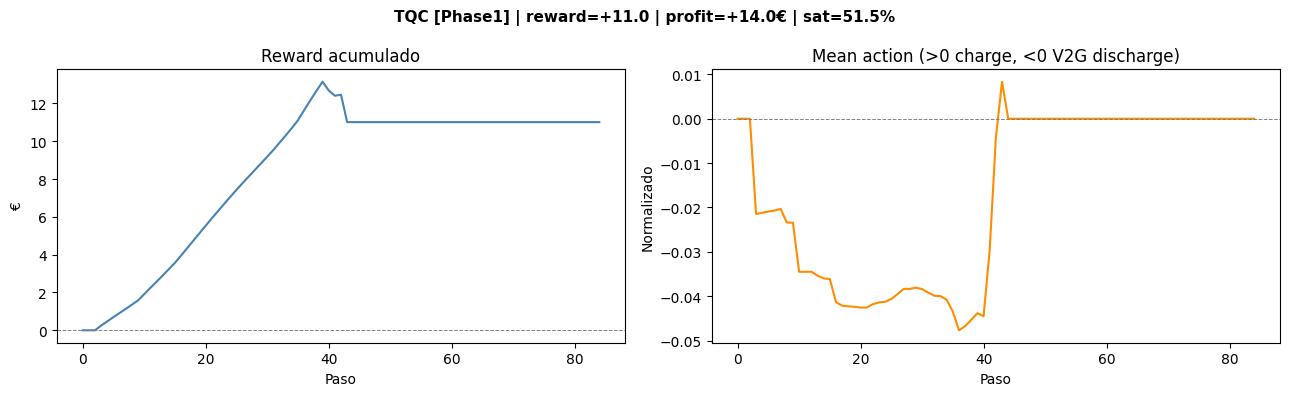

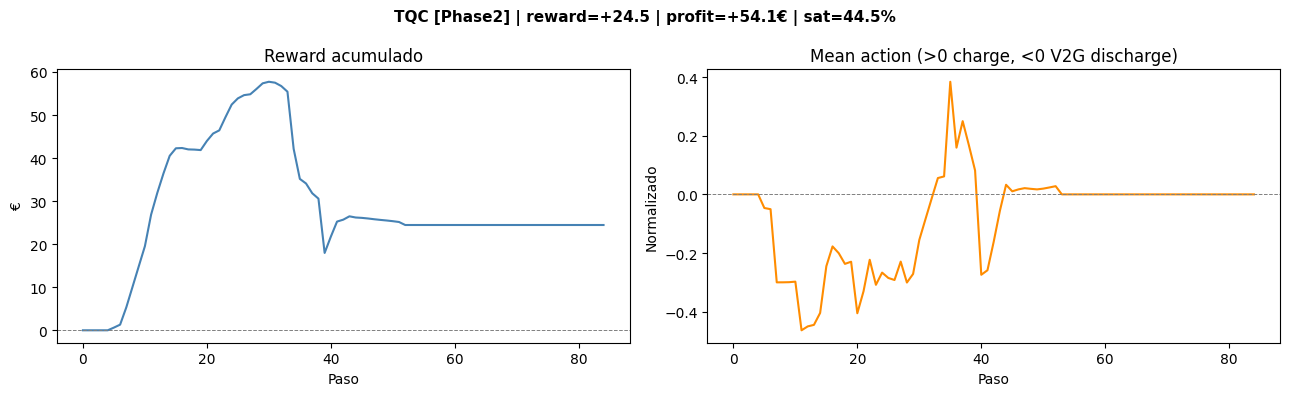

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# Policy traces: representative episode
# ─────────────────────────────────────────────────────────────────────────────

def plot_policy_traces(episodes: List[dict], df_eps: pd.DataFrame,
                       label: str, save_path: Path):
    if len(episodes) == 0:
        return
    median_r = df_eps["reward_total"].median()
    rep_idx  = (df_eps["reward_total"] - median_r).abs().idxmin()
    rep_ep   = episodes[rep_idx]
    steps    = np.arange(len(rep_ep["ts_reward"]))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(steps, rep_ep["ts_cum_reward"], color="steelblue")
    axes[0].axhline(0, color="gray", lw=0.7, ls="--")
    axes[0].set_title("Reward acumulado"); axes[0].set_xlabel("Paso"); axes[0].set_ylabel("€")

    axes[1].plot(steps, rep_ep["ts_action"], color="darkorange")
    axes[1].axhline(0, color="gray", lw=0.7, ls="--")
    axes[1].set_title("Mean action (>0 charge, <0 V2G discharge)")
    axes[1].set_xlabel("Paso"); axes[1].set_ylabel("Normalizado")

    fig.suptitle(f"TQC [{label}] | reward={rep_ep['reward_total']:+.1f} | "
                 f"profit={rep_ep['total_profit_cost']:+.1f}€ | "
                 f"sat={rep_ep['user_satisfaction']:.1%}",
                 fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

plot_policy_traces(eps_p1, df_eps_p1, "Phase1", RESULTS_ROOT / "traces_phase1.png")
plot_policy_traces(eps_p2, df_eps_p2, "Phase2", RESULTS_ROOT / "traces_phase2.png")


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Exportar Excel
# ─────────────────────────────────────────────────────────────────────────────

def eps_to_df(episodes, label):
    rows = [{k: v for k, v in e.items()
             if k in SCALAR_COLS + ["episode","seed","phase"]}
            for e in episodes]
    df = pd.DataFrame(rows)
    df.insert(0, "algorithm", label)
    return df

def tabla7_row(episodes, label):
    df  = pd.DataFrame([{k: v for k, v in e.items() if k in SCALAR_COLS}
                        for e in episodes])
    row = {"Algorithm": label}
    for col in SCALAR_COLS:
        if col in df.columns:
            row[f"{col}_mean"] = round(df[col].mean(), 6)
            row[f"{col}_std"]  = round(df[col].std(ddof=1) if len(df)>1 else 0.0, 6)
    return row

# Paper reference row for direct comparison
paper_ref = {
    "Algorithm"                    : "Paper_TQC_ref",
    "reward_total_mean"            : -3500.0, "reward_total_std"            : 5600.0,
    "total_profit_cost_mean"       : 1.9,     "total_profit_cost_std"       : 21.6,
    "user_satisfaction_mean"       : 0.72,    "user_satisfaction_std"       : 0.24,
    "energy_charged_kwh_mean"      : 66.0,    "energy_charged_kwh_std"      : 39.0,
    "energy_discharged_kwh_mean"   : 62.0,    "energy_discharged_kwh_std"   : 58.0,
    "transformer_overload_kwh_mean": 35.0,    "transformer_overload_kwh_std": 56.0,
    "battery_degradation_mean"     : 0.53e-3, "battery_degradation_std"     : 0.13e-3,
    "exec_time_s_mean"             : 0.16,    "exec_time_s_std"             : 0.02,
}

df_eps_all = pd.concat([eps_to_df(eps_p1,"TQC_Phase1"),
                         eps_to_df(eps_p2,"TQC_Phase2")], ignore_index=True)

df_tabla7  = pd.DataFrame([
    tabla7_row(eps_p1, "TQC_Phase1"),
    tabla7_row(eps_p2, "TQC_Phase2"),
    paper_ref,
])

df_opt = pd.DataFrame([
    {"phase":"Phase1","best_value":study1.best_value,
     "n_trials":PHASE1_N_TRIALS,"timesteps_trial":PHASE1_TIMESTEPS,"yaml_tuned":False},
    {"phase":"Phase2","best_value":study2.best_value,
     "n_trials":PHASE2_N_TRIALS,"timesteps_trial":PHASE2_TIMESTEPS,"yaml_tuned":True},
])

df_hps = pd.DataFrame([
    {"phase":"Phase1","optuna_value":study1.best_value,
     "total_timesteps":TOTAL_TIMESTEPS,"n_envs":N_ENVS,
     "pi_arch":str(best_arch_p1["pi"]),"qf_arch":str(best_arch_p1["qf"]),**best_hp_p1},
    {"phase":"Phase2","optuna_value":study2.best_value,
     "total_timesteps":TOTAL_TIMESTEPS,"n_envs":N_ENVS,
     "pi_arch":str(best_arch_p2["pi"]),"qf_arch":str(best_arch_p2["qf"]),**best_hp_p2,
     "yaml_spawn":p2.get("spawn_multiplier"),
     "yaml_discharge_factor":p2.get("discharge_price_factor"),
     "yaml_transformer_kw":p2.get("transformer_max_power")},
])

# ── Convergence curves ───────────────────────────────────────────────────────
df_conv_p1 = pd.read_csv(RESULTS_ROOT / "optuna_phase1_convergence.csv")
df_conv_p2 = pd.read_csv(RESULTS_ROOT / "optuna_phase2_convergence.csv")
df_convergence = pd.concat([df_conv_p1, df_conv_p2], ignore_index=True)

# ── Update REPRO_LOG with final values ───────────────────────────────────────
REPRO_LOG.update({
    "phase1_optuna_best_value": float(study1.best_value),
    "phase2_optuna_best_value": float(study2.best_value),
    "phase1_best_trial": int(study1.best_trial.number),
    "phase2_best_trial": int(study2.best_trial.number),
    "phase1_total_eval_episodes": len(eps_p1),
    "phase2_total_eval_episodes": len(eps_p2),
    "phase1_yaml": str(PHASE1_BEST_YAML),
    "phase2_yaml": str(PHASE2_BEST_YAML),
    "phase2_yaml_params": {
        "spawn_multiplier"      : best_cfg_p2.get("spawn_multiplier"),
        "discharge_price_factor": best_cfg_p2.get("discharge_price_factor"),
        "transformer_max_power" : best_cfg_p2.get("transformer", {}).get("max_power"),
    },
    "phase1_best_hps": best_hp_p1,
    "phase2_best_hps": best_hp_p2,
})
with open(RESULTS_ROOT / "reproducibility_log.json", "w") as f:
    json.dump(REPRO_LOG, f, indent=2)
print("Reproducibility log saved.")

out = RESULTS_ROOT / "tqc_model1_report.xlsx"
with pd.ExcelWriter(out) as w:
    df_eps_all.to_excel(w,    sheet_name="episodes_all",       index=False)
    df_tabla7.to_excel( w,    sheet_name="tabla7_vs_paper",    index=False)
    df_all_sum.to_excel(w,    sheet_name="summary_full",       index=False)
    df_eps_p1.to_excel( w,    sheet_name="regime_phase1",      index=False)
    df_eps_p2.to_excel( w,    sheet_name="regime_phase2",      index=False)
    df_opt.to_excel(    w,    sheet_name="optuna_comparison",  index=False)
    df_hps.to_excel(    w,    sheet_name="best_hyperparams",   index=False)
    df_convergence.to_excel(w, sheet_name="optuna_convergence", index=False)

print(f"Excel report: {out}")
df_eps_all.to_csv(   RESULTS_ROOT / "episodes_all.csv",           index=False)
df_tabla7.to_csv(    RESULTS_ROOT / "tabla7_vs_paper.csv",        index=False)
df_convergence.to_csv(RESULTS_ROOT / "optuna_convergence_both.csv", index=False)
print("CSVs saved.")


Reproducibility log saved.
Excel report: results_tqc_model1/tqc_model1_report.xlsx
CSVs saved.


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Final summary
# ─────────────────────────────────────────────────────────────────────────────

def arr(eps, col): return np.array([e[col] for e in eps])

r1  = arr(eps_p1,"reward_total");  r2  = arr(eps_p2,"reward_total")
pr1 = arr(eps_p1,"total_profit_cost"); pr2 = arr(eps_p2,"total_profit_cost")
s1  = arr(eps_p1,"user_satisfaction"); s2  = arr(eps_p2,"user_satisfaction")
ov1 = arr(eps_p1,"transformer_overload_kwh"); ov2 = arr(eps_p2,"transformer_overload_kwh")
q1  = arr(eps_p1,"battery_degradation");      q2  = arr(eps_p2,"battery_degradation")

def fmt(a, mult=1):
    if len(a) < 2: return f"{a.mean()*mult:+.2f} (n=1)"
    return f"{a.mean()*mult:+.2f} ± {a.std(ddof=1)*mult:.2f}"

sep = "=" * 72
print(sep)
print("  TQC Model 1 — RESUMEN")
print(f"  Steps: {TOTAL_TIMESTEPS:,} | Envs: {N_ENVS} | Eps eval: {len(eps_p1)}/fase")
print(sep)
print(f"  {'Metric':<28} {'Phase 1 (HPs)':>20}   {'Phase 2 (HPs+YAML)':>20}   {'Paper ref':>15}")
print(f"  {'-'*70}")
rows = [
    ("Reward",         r1,  r2,  "-3500±5600", 1),
    ("Profit (€)",     pr1, pr2, "1.9±21.6",   1),
    ("User sat. (%)",  s1,  s2,  "72±24",      100),
    ("Overload (kWh)", ov1, ov2, "35±56",      1),
    ("Q_lost (×10⁻³)", q1, q2,  "—",           1e3),
]
for lbl, a1, a2, paper, mult in rows:
    print(f"  {lbl:<28} {fmt(a1,mult):>20}   {fmt(a2,mult):>20}   {paper:>15}")

# ── Battery degradation monetization  ────────
LI_ION_EUR_PER_KWH = 150.0
BAT_CAP_KWH        = 70.0
print(sep)
print("  BATTERY DEGRADATION COST ESTIMATE :")
print(f"  Li-ion replacement: €{LI_ION_EUR_PER_KWH:.0f}/kWh × {BAT_CAP_KWH:.0f} kWh/battery")
for _phase, _q in [("Phase1", q1), ("Phase2", q2)]:
    _degrad_eur = _q * BAT_CAP_KWH * LI_ION_EUR_PER_KWH
    print(f"  [{_phase}] Q_lost={_q.mean()*1e3:.3f}±{_q.std(ddof=1)*1e3:.3f}×10⁻³"
          f"  →  degrad_cost≈{_degrad_eur.mean():.2f}±{_degrad_eur.std(ddof=1):.2f} €/ep")
print("  NOTE: degradation cost is not part of the reward — net profit = reported profit − degrad_cost")

print(sep)
# ── Statistical caution ───────────────────────────────────────────────────────
print("\nSTATISTICAL NOTE:")
for label, arr_data, nm in [("Phase1", pr1, "Profit"), ("Phase2", pr2, "Profit"),
                              ("Phase1", s1,  "Sat"),    ("Phase2", s2,  "Sat")]:
    if len(arr_data) > 1:
        mn, sd = arr_data.mean(), arr_data.std(ddof=1)
        flag = " ← std > mean — treat ranking as directional only" \
               if abs(sd) > abs(mn) and mn != 0 else ""
        print(f"  TQC [{label}] {nm}: {mn:+.2f} ± {sd:.2f}{flag}")
print(sep)


  TQC Model 1 — RESUMEN
  Steps: 1,000,000 | Envs: 30 | Eps eval: 100/fase
  Metric                              Phase 1 (HPs)     Phase 2 (HPs+YAML)         Paper ref
  ----------------------------------------------------------------------
  Reward                             +17.95 ± 19.71         +42.31 ± 46.73        -3500±5600
  Profit (€)                         +26.19 ± 28.63         +67.07 ± 58.47          1.9±21.6
  User sat. (%)                      +49.81 ± 10.00         +44.01 ± 11.05             72±24
  Overload (kWh)                       +0.00 ± 0.00           +0.00 ± 0.00             35±56
  Q_lost (×10⁻³)                       +0.20 ± 0.09           +0.79 ± 0.29                 —
  BATTERY DEGRADATION COST ESTIMATE :
  Li-ion replacement: €150/kWh × 70 kWh/battery
  [Phase1] Q_lost=0.197±0.086×10⁻³  →  degrad_cost≈2.07±0.90 €/ep
  [Phase2] Q_lost=0.790±0.287×10⁻³  →  degrad_cost≈8.30±3.01 €/ep
  NOTE: degradation cost is not part of the reward — net profit = reported p

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
#   Bootstrap CIs + Wilcoxon signed-rank tests
#  Ref: Agarwal et al. NeurIPS 2021 'Deep RL at the Statistical Precipice'
#
#  TEST      → N_BOOTSTRAP = 100    (seconds)
#  PRODUCTION  → N_BOOTSTRAP = 10_000  (minutes — publishable results)
# ─────────────────────────────────────────────────────────────────────────────

from scipy import stats as scipy_stats

N_BOOTSTRAP = 100          # TEST → production: 10_000

def bootstrap_ci(data, stat_fn=np.mean, n=N_BOOTSTRAP, ci=0.95):
    rng  = np.random.default_rng(42)
    boot = [stat_fn(rng.choice(data, size=len(data), replace=True)) for _ in range(n)]
    alpha = (1 - ci) / 2
    return np.percentile(boot, [alpha*100, (1-alpha)*100])

def wilcoxon_test(a, b):
    n = min(len(a), len(b))
    try:
        stat, p = scipy_stats.wilcoxon(a[:n], b[:n])
        return {'stat': float(stat), 'p_value': float(p),
                'significant_at_05': bool(p < 0.05)}
    except Exception as e:
        return {'stat': None, 'p_value': None, 'error': str(e)}

print(f'Bootstrap CIs (N={N_BOOTSTRAP}) + Wilcoxon tests')
print('='*65)

metrics_ci = [
    ('total_profit_cost',        'Profit (euro)',      1),
    ('user_satisfaction',        'User sat. (%)',      100),
    ('transformer_overload_kwh', 'Overload (kWh)',     1),
    ('battery_degradation',      'Q_lost (x10^-3)',    1e3),
]

ci_results = {}
for col, lbl, mult in metrics_ci:
    a1 = np.array([e[col]*mult for e in eps_p1])
    a2 = np.array([e[col]*mult for e in eps_p2])
    lo1, hi1 = bootstrap_ci(a1)
    lo2, hi2 = bootstrap_ci(a2)
    wtest    = wilcoxon_test(
        np.array([e[col] for e in eps_p1]),
        np.array([e[col] for e in eps_p2]))
    ci_results[col] = {
        'phase1_mean': float(a1.mean()), 'phase1_ci95': [float(lo1), float(hi1)],
        'phase2_mean': float(a2.mean()), 'phase2_ci95': [float(lo2), float(hi2)],
        'wilcoxon_p1_vs_p2': wtest,
    }
    sig = '* p<0.05' if wtest.get('significant_at_05') else 'ns'
    print(f'\n  {lbl}')
    print(f'    F1: {a1.mean():+.3f}  95% CI [{lo1:+.3f}, {hi1:+.3f}]')
    print(f'    F2: {a2.mean():+.3f}  95% CI [{lo2:+.3f}, {hi2:+.3f}]')
    pval = wtest.get('p_value')
    pstr = f'{pval:.4f}' if pval is not None else 'N/A'
    print(f'    Wilcoxon F1 vs F2: p={pstr}  {sig}')

with open(RESULTS_ROOT / 'bootstrap_ci_results.json', 'w') as f:
    json.dump(ci_results, f, indent=2)
print(f'\nSaved: bootstrap_ci_results.json  (N_BOOTSTRAP={N_BOOTSTRAP})')
print('For production: cambiar N_BOOTSTRAP = 10_000')


Bootstrap CIs (N=100) + Wilcoxon tests

  Profit (euro)
    F1: +26.187  95% CI [+21.322, +32.309]
    F2: +67.069  95% CI [+57.123, +79.580]
    Wilcoxon F1 vs F2: p=0.0000  * p<0.05

  User sat. (%)
    F1: +49.809  95% CI [+47.642, +51.649]
    F2: +44.009  95% CI [+42.026, +46.493]
    Wilcoxon F1 vs F2: p=0.0000  * p<0.05

  Overload (kWh)
    F1: +0.000  95% CI [+0.000, +0.000]
    F2: +0.000  95% CI [+0.000, +0.000]
    Wilcoxon F1 vs F2: p=N/A  ns

  Q_lost (x10^-3)
    F1: +0.197  95% CI [+0.181, +0.212]
    F2: +0.790  95% CI [+0.750, +0.837]
    Wilcoxon F1 vs F2: p=0.0000  * p<0.05

Saved: bootstrap_ci_results.json  (N_BOOTSTRAP=100)
For production: cambiar N_BOOTSTRAP = 10_000


In [1]:
# ─────────────────────────────────────────────────────────────────────────────
#   Sensitivity: HPO budget (n_trials)
#  ¿30 trials es suficiente? Corremos estudios con distintos budgets y
#  comparamos la curva best-so-far para verificar convergencia.
#  Ref: Hertel et al.; 
#
#  Valores TEST/PROD vienen de la celda MODE (celda 1).
#  TEST:  SENSITIVITY_TRIALS=[3,5],   SENSITIVITY_STEPS=2_000    → minutos
#  PROD:  SENSITIVITY_TRIALS=[30,60,100], SENSITIVITY_STEPS=100_000 → horas
# ─────────────────────────────────────────────────────────────────────────────

SENSITIVITY_SEED = 42
# SENSITIVITY_TRIALS y SENSITIVITY_STEPS vienen de celda MODE

def run_sensitivity_study(n_trials, study_id=0):
    set_seed(SENSITIVITY_SEED)
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SENSITIVITY_SEED),
        study_name=f'tqc_sensitivity_{study_id}_{n_trials}t',
        load_if_exists=True,
    )
    def obj(trial):
        arch = sample_tqc_arch(trial)
        hp   = sample_tqc_hparams(trial)
        yp   = save_cfg(BASE_CFG,
            RESULTS_ROOT / f'sens_{study_id}_{trial.number}.yaml')
        try:
            te = make_vec_train_env_optuna(
                str(yp), seed=SENSITIVITY_SEED, n_envs=2)
            m  = build_tqc(hp, arch, te,                           # FIX: era build_model
                seed=SENSITIVITY_SEED, n_envs=2)
            m.learn(total_timesteps=SENSITIVITY_STEPS)
            vp = str(RESULTS_ROOT / f'sens_vn_{study_id}_{trial.number}.pkl')
            te.save(vp); te.close()
            score = quick_eval(m, str(yp), vp, n_eps=4)
            return score
        except Exception as e:
            print(f'  Trial {trial.number} error: {e}')
            return -1e9
    study.optimize(obj, n_trials=n_trials, show_progress_bar=False)
    best, curve = -float('inf'), []
    for t in sorted(study.trials, key=lambda x: x.number):
        if t.value is not None and t.value > best and t.value > -1e8:
            best = t.value
        curve.append({'trial': t.number, 'value': t.value,
                      'best_so_far': best if best > -1e8 else None,
                      'n_trials_budget': n_trials})
    n_failed = sum(1 for t in study.trials if t.value is None or t.value <= -1e8)
    print(f'  Failed trials: {n_failed}/{n_trials}')
    try:
        bv = study.best_value
    except ValueError:
        bv = -1e9
    return curve, bv

print(f'HPO budget sensitivity | trials: {SENSITIVITY_TRIALS}')
print(f'Steps per trial: {SENSITIVITY_STEPS:,}')
print('='*55)

all_curves = []
for sid, n_t in enumerate(SENSITIVITY_TRIALS):
    print(f'\nRunning {n_t} trials...')
    t0 = time.time()
    curve, best_val = run_sensitivity_study(n_t, study_id=sid)
    all_curves.extend(curve)
    elapsed = (time.time()-t0)/60
    if best_val <= -1e8:
        print(f'  ⚠ ALL TRIALS FAILED — check errors above')
    else:
        print(f'  Best: {best_val:.3f} | Time: {elapsed:.1f} min')

df_sens = pd.DataFrame(all_curves)
df_sens.to_csv(RESULTS_ROOT / 'sensitivity_hpo_budget.csv', index=False)

# Only plot if there were successful trials
df_ok = df_sens[df_sens['best_so_far'].notna()]
if len(df_ok) > 0:
    fig, ax = plt.subplots(figsize=(9, 5))
    for sid, n_t in enumerate(SENSITIVITY_TRIALS):
        sub = df_ok[df_ok['n_trials_budget'] == n_t]
        if len(sub) == 0: continue
        bsf = sub['best_so_far'].iloc[-1]
        ax.plot(sub['trial'], sub['best_so_far'], marker='o', ms=4,
                label=f'{n_t} trials (best={bsf:.2f})')
    ax.set_xlabel('Trial #'); ax.set_ylabel('Best score so far')
    ax.set_title('Sensitivity: HPO budget'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_ROOT / 'sensitivity_hpo_budget.png', dpi=150)
    plt.show()
    print('Saved: sensitivity_hpo_budget.csv + .png')
else:
    print('Sin successful trials — check configuration del entorno')

NameError: name 'SENSITIVITY_TRIALS' is not defined

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
#  Ablation: proxy reward (Model-2) vs direct (Model-1)
#
#  Entrena UNA run adicional con el reward real (sparse, Model-1)
#  y compara contra el agente proxy ya entrenado arriba.
#  Usa los best HPs de F1 para aislar el efecto del reward.
#
#  Valores TEST/PROD vienen de la celda MODE (celda 1).
#  TEST: ABLATION_TIMESTEPS=5_000  → expected result: small difference
#        (with few steps both models barely learn — expected in TEST mode)
#  PROD: ABLATION_TIMESTEPS=1_000_000 → diferencia real y significativa
#
#  NOTA: In TEST mode near-identical results are expected — insufficient steps for divergence.
#  The proxy vs. direct difference only appears clearly with full training (1M steps).
# ─────────────────────────────────────────────────────────────────────────────

from ev2gym.rl_agent.reward import profit_maximization as model1_reward

# ABLATION_TIMESTEPS y ABLATION_N_ENVS vienen de celda MODE

def make_vec_direct_env(config_file, seed=42, n_envs=4):
    'Training environment with direct Model-1 reward (sparse, no proxy).'
    def _make():
        import gymnasium as gym
        return gym.make('EV2Gym-v1',
                        config_file=config_file,
                        reward_function=model1_reward,
                        state_function=V2G_profit_max)
    venv = SubprocVecEnv([_make]*n_envs) if n_envs > 1 else DummyVecEnv([_make])
    return VecNormalize(venv, norm_obs=True, norm_reward=True,
                        clip_obs=10.0, clip_reward=10.0)

print('Proxy reward ablation: Model-2 (proxy) vs Model-1 (direct)')
print(f'Timesteps: {ABLATION_TIMESTEPS:,} | Envs: {ABLATION_N_ENVS}')
print(f'Note: con TEST ({ABLATION_TIMESTEPS:,} steps) results will be')
print(f'      near-identical — the real difference only appears in PROD (1M steps).')
print('='*55)

set_seed(42)
te_direct = make_vec_direct_env(
    str(PHASE1_BEST_YAML), seed=42, n_envs=ABLATION_N_ENVS)
m_direct  = build_tqc(best_hp_p1, best_arch_p1, te_direct,
                         seed=42, n_envs=ABLATION_N_ENVS)
print('Training with direct Model-1 reward...')
t0 = time.time()
m_direct.learn(total_timesteps=ABLATION_TIMESTEPS, progress_bar=True)
print(f'Completed in {(time.time()-t0)/60:.1f} min')
vn_abl = str(RESULTS_ROOT / 'vecnorm_ablation_direct.pkl')
m_direct.save(str(RESULTS_ROOT / 'model_ablation_direct'))
te_direct.save(vn_abl)
te_direct.close()

print('\nEvaluating ambos...')
eps_proxy  = evaluate_model(model_p1, PHASE1_BEST_YAML, vn_path_p1, 'Proxy_M2')
eps_direct = evaluate_model(m_direct, PHASE1_BEST_YAML, vn_abl,      'Direct_M1')

print('\nABLATION RESULTS:')
for lbl, eps in [('Proxy (Model-2)', eps_proxy), ('Direct (Model-1)', eps_direct)]:
    pr  = np.array([e['total_profit_cost']       for e in eps])
    sat = np.array([e['user_satisfaction']        for e in eps])
    ov  = np.array([e['transformer_overload_kwh'] for e in eps])
    print(f'  {lbl:<22} profit={pr.mean():+.2f}+/-{pr.std():.2f}  '
          f'sat={sat.mean():.1%}  ov={ov.mean():.1f} kWh')

if ABLATION_TIMESTEPS < 100_000:
    print()
    print('TEST NOTE: With few steps both models barely learn.')
    print('Near-identical results are expected in TEST mode.')
    print("Set MODE='PROD' to observe the true difference (1M steps).")

df_abl = pd.concat([
    pd.DataFrame([{k:v for k,v in e.items()
                   if k in SCALAR_COLS+['episode','seed','phase']}
                  for e in eps_proxy]),
    pd.DataFrame([{k:v for k,v in e.items()
                   if k in SCALAR_COLS+['episode','seed','phase']}
                  for e in eps_direct]),
], ignore_index=True)
df_abl.to_csv(RESULTS_ROOT / 'ablation_proxy_vs_direct.csv', index=False)
print('\nSaved: ablation_proxy_vs_direct.csv')


Proxy reward ablation: Model-2 (proxy) vs Model-1 (direct)
Timesteps: 1,000,000 | Envs: 4
Note: con TEST (1,000,000 steps) results will be
      near-identical — the real difference only appears in PROD (1M steps).
Training with direct Model-1 reward...


Output()

Completed in 555.9 min

Evaluating ambos...
  [Proxy_M2] Ep  1 | reward=+11.0 | profit=+14.0€ | sat=51.5% | overload=0.0kWh | Qlost=0.00016 | EVs=4
  [Proxy_M2] Ep  2 | reward=+4.3 | profit=+6.4€ | sat=54.9% | overload=0.0kWh | Qlost=0.00010 | EVs=4
  [Proxy_M2] Ep  3 | reward=+20.0 | profit=+29.9€ | sat=37.7% | overload=0.0kWh | Qlost=0.00016 | EVs=3
  [Proxy_M2] Ep  4 | reward=+61.7 | profit=+104.0€ | sat=30.5% | overload=0.0kWh | Qlost=0.00037 | EVs=5
  [Proxy_M2] Ep  5 | reward=+71.2 | profit=+109.6€ | sat=36.3% | overload=0.0kWh | Qlost=0.00036 | EVs=7
  [Proxy_M2] Ep  6 | reward=+52.2 | profit=+62.2€ | sat=44.2% | overload=0.0kWh | Qlost=0.00026 | EVs=5
  [Proxy_M2] Ep  7 | reward=+52.3 | profit=+77.3€ | sat=30.1% | overload=0.0kWh | Qlost=0.00026 | EVs=4
  [Proxy_M2] Ep  8 | reward=+4.7 | profit=+5.7€ | sat=60.7% | overload=0.0kWh | Qlost=0.00011 | EVs=3
  [Proxy_M2] Ep  9 | reward=+6.6 | profit=+8.6€ | sat=58.3% | overload=0.0kWh | Qlost=0.00015 | EVs=6
  [Proxy_M2] Ep 10 | rew

## Modificaciones a TQC para Sensibilidad

In [2]:
# ═══════════════════════════════════════════════════════════════════════════
#  STANDALONE SETUP — sensitivity sin reentrenar
#  Ejecutar solo esta celda + celda B para correr la sensitivity
#  usando resultados ya guardados en disco.
# ═══════════════════════════════════════════════════════════════════════════
import copy, json, time, warnings, random
from pathlib import Path
from typing import Any, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

import torch
import sys
import gymnasium as gym
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize, SubprocVecEnv
from sb3_contrib import TQC

from ev2gym.rl_agent.reward import profit_maximization
from ev2gym.rl_agent.state  import V2G_profit_max

START_METHOD = "fork" if sys.platform.startswith("linux") else "spawn"

# ── Apunta a los resultados de producción ya guardados ──────────────────────
RESULTS_ROOT = Path("/home/aia-workstation/Documents/Abraham/PROD/results_tqc_model1")
assert RESULTS_ROOT.exists(), f"No existe: {RESULTS_ROOT}"

# ── Parámetros de sensitivity (PROD) ────────────────────────────────────────
SENSITIVITY_TRIALS = [30, 60, 100]
SENSITIVITY_STEPS  = 100_000
N_ENVS = 4   # usado por make_vec_train_env_optuna default

# ── Reconstruir BASE_CFG desde el YAML guardado ─────────────────────────────
MODEL1_YAML_PATH = RESULTS_ROOT / "model1_base.yaml"
assert MODEL1_YAML_PATH.exists(), f"No existe: {MODEL1_YAML_PATH}"
with open(MODEL1_YAML_PATH) as f:
    BASE_CFG = yaml.safe_load(f)

def save_cfg(cfg: dict, path) -> str:
    out = {}
    for k, v in cfg.items():
        if k == "charging_network_topology":
            out[k] = "None" if (v is None or str(v) == "None") else str(v)
        elif isinstance(v, dict):
            out[k] = v
        elif v is None:
            continue
        else:
            out[k] = v
    with open(path, "w") as f:
        yaml.dump(out, f, default_flow_style=False, allow_unicode=True)
    return str(path)

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def make_env_raw(config_file: str):
    return gym.make("EV2Gym-v1",
                    config_file=config_file,
                    reward_function=profit_maximization,
                    state_function=V2G_profit_max)

def make_vec_train_env_optuna(config_file: str, seed: int = 42, n_envs: int = 4) -> VecNormalize:
    def make_fn(rank):
        def _init():
            env = make_env_raw(config_file)
            env.reset(seed=seed + rank)
            return env
        return _init
    vec = SubprocVecEnv([make_fn(i) for i in range(n_envs)], start_method=START_METHOD)
    return VecNormalize(vec, norm_obs=True, norm_reward=True, clip_obs=10.0)

def load_eval_env(config_file: str, vecnorm_path: str) -> VecNormalize:
    vec = DummyVecEnv([lambda cf=config_file: make_env_raw(cf)])
    vn  = VecNormalize.load(vecnorm_path, vec)
    vn.training    = False
    vn.norm_reward = False
    return vn

def build_tqc(hp: dict, arch: dict, env, seed: int = 42, n_envs: int = 1) -> TQC:
    policy_kwargs = dict(
        net_arch    = dict(pi=arch["pi"], qf=arch["qf"]),
        n_quantiles = hp.get("n_quantiles", 25),
        n_critics   = hp.get("n_critics",   2),
        share_features_extractor = False,
    )
    gs = -1 if n_envs > 1 else hp.get("gradient_steps", 1)
    return TQC("MlpPolicy", env,
        learning_rate                 = hp.get("learning_rate",    3e-4),
        gamma                         = hp.get("gamma",            0.99),
        batch_size                    = hp.get("batch_size",       256),
        tau                           = hp.get("tau",              0.005),
        buffer_size                   = hp.get("buffer_size",      1_000_000),
        learning_starts               = hp.get("learning_starts",  100),
        train_freq                    = hp.get("train_freq",       1),
        gradient_steps                = gs,
        ent_coef                      = hp.get("ent_coef",         "auto"),
        target_update_interval        = hp.get("target_update_interval", 1),
        top_quantiles_to_drop_per_net = hp.get("top_quantiles_to_drop_per_net", 2),
        use_sde                       = hp.get("use_sde",          False),
        sde_sample_freq               = hp.get("sde_sample_freq",  -1),
        n_steps                       = hp.get("n_steps",          1),
        policy_kwargs                 = policy_kwargs,
        verbose                       = 0,
        seed                          = seed,
    )

def quick_eval(model, config_file: str, vecnorm_path: str, n_eps: int) -> float:
    eval_env = load_eval_env(config_file, vecnorm_path)
    rewards  = []
    for _ in range(n_eps):
        obs  = eval_env.reset()
        done = [False]
        ep_r = 0.0
        while not done[0]:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, done, _ = eval_env.step(action)
            ep_r += float(r[0])
        rewards.append(ep_r)
    eval_env.close()
    return float(np.mean(rewards))

def sample_tqc_arch(trial: optuna.Trial) -> dict:
    sizes = [64, 128, 256, 512, 1024]
    pi_n  = trial.suggest_int("pi_layers", 2, 4)
    qf_n  = trial.suggest_int("qf_layers", 2, 4)
    pi    = [trial.suggest_categorical(f"pi_l{i}", sizes) for i in range(pi_n)]
    qf    = [trial.suggest_categorical(f"qf_l{i}", sizes) for i in range(qf_n)]
    return {"pi": pi, "qf": qf}

def sample_tqc_hparams(trial: optuna.Trial) -> dict:
    return {
        "learning_rate"               : trial.suggest_float("lr",     1e-5, 3e-3, log=True),
        "gamma"                       : trial.suggest_float("gamma",  0.90, 0.999),
        "tau"                         : trial.suggest_float("tau",    1e-3, 5e-2, log=True),
        "batch_size"                  : trial.suggest_categorical("bs",      [128, 256, 512, 1024]),
        "buffer_size"                 : trial.suggest_categorical("buf",     [100_000, 500_000, 1_000_000]),
        "learning_starts"             : trial.suggest_categorical("lstarts", [1_000, 5_000, 10_000]),
        "train_freq"                  : trial.suggest_categorical("tf",      [1, 4, 8]),
        "gradient_steps"              : trial.suggest_categorical("gs",      [1, 4, 8]),
        "n_quantiles"                 : trial.suggest_categorical("nq",      [25, 50, 100]),
        "top_quantiles_to_drop_per_net": trial.suggest_int("tqdrop",  1, 5),
        "n_critics"                   : trial.suggest_categorical("nc",      [2, 3, 5]),
        "target_update_interval"      : trial.suggest_categorical("tui",     [1, 2, 4]),
        "ent_coef"                    : trial.suggest_categorical("ent",     ["auto", 0.1, 0.01, 0.001]),
        "use_sde"                     : trial.suggest_categorical("use_sde", [True, False]),
        "sde_sample_freq"             : -1,
        "n_steps"                     : trial.suggest_categorical("n_steps", [1, 3, 5, 10]),
    }

print(f"Setup OK | RESULTS_ROOT: {RESULTS_ROOT}")
print(f"BASE_CFG cargado desde: {MODEL1_YAML_PATH}")
print(f"Sensitivity: {SENSITIVITY_TRIALS} trials × {SENSITIVITY_STEPS:,} steps")

Setup OK | RESULTS_ROOT: /home/aia-workstation/Documents/Abraham/PROD/results_tqc_model1
BASE_CFG cargado desde: /home/aia-workstation/Documents/Abraham/PROD/results_tqc_model1/model1_base.yaml
Sensitivity: [30, 60, 100] trials × 100,000 steps


HPO budget sensitivity | trials: [30, 60, 100]
Steps per trial: 100,000

Running 30 trials...
  Failed trials: 0/30
  Best: 27.255 | Time: 939.0 min

Running 60 trials...
  Failed trials: 0/60
  Best: 31.732 | Time: 1699.6 min

Running 100 trials...
  Failed trials: 0/100
  Best: 32.707 | Time: 2598.9 min


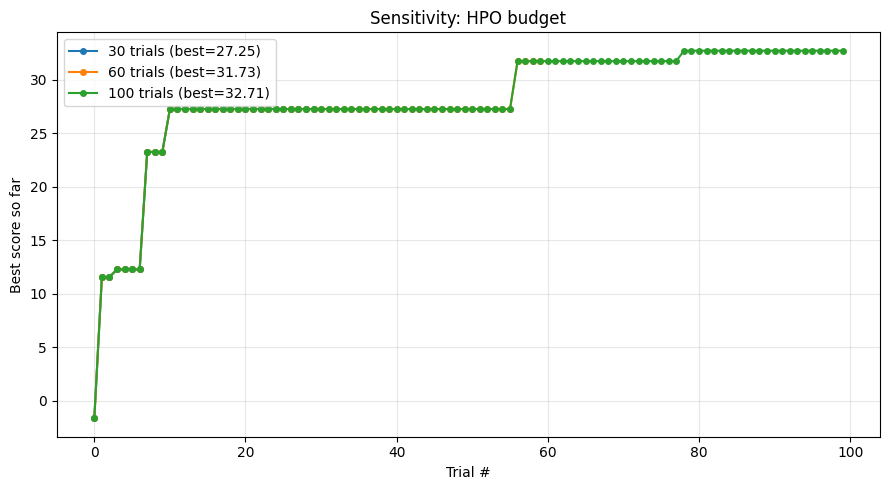

Saved: sensitivity_hpo_budget.csv + .png


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
#   Sensitivity: HPO budget (n_trials)
# ─────────────────────────────────────────────────────────────────────────────

SENSITIVITY_SEED = 42

def run_sensitivity_study(n_trials, study_id=0):
    set_seed(SENSITIVITY_SEED)
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SENSITIVITY_SEED),
        study_name=f'tqc_sensitivity_{study_id}_{n_trials}t',
        load_if_exists=True,
    )
    def obj(trial):
        arch = sample_tqc_arch(trial)
        hp   = sample_tqc_hparams(trial)
        yp   = save_cfg(BASE_CFG,
            RESULTS_ROOT / f'sens_{study_id}_{trial.number}.yaml')
        try:
            te = make_vec_train_env_optuna(
                str(yp), seed=SENSITIVITY_SEED, n_envs=2)
            m  = build_tqc(hp, arch, te,
                seed=SENSITIVITY_SEED, n_envs=2)
            m.learn(total_timesteps=SENSITIVITY_STEPS)
            vp = str(RESULTS_ROOT / f'sens_vn_{study_id}_{trial.number}.pkl')
            te.save(vp); te.close()
            score = quick_eval(m, str(yp), vp, n_eps=4)
            return score
        except Exception as e:
            print(f'  Trial {trial.number} error: {e}')
            return -1e9
    study.optimize(obj, n_trials=n_trials, show_progress_bar=False)
    best, curve = -float('inf'), []
    for t in sorted(study.trials, key=lambda x: x.number):
        if t.value is not None and t.value > best and t.value > -1e8:
            best = t.value
        curve.append({'trial': t.number, 'value': t.value,
                      'best_so_far': best if best > -1e8 else None,
                      'n_trials_budget': n_trials})
    n_failed = sum(1 for t in study.trials if t.value is None or t.value <= -1e8)
    print(f'  Failed trials: {n_failed}/{n_trials}')
    try:
        bv = study.best_value
    except ValueError:
        bv = -1e9
    return curve, bv

print(f'HPO budget sensitivity | trials: {SENSITIVITY_TRIALS}')
print(f'Steps per trial: {SENSITIVITY_STEPS:,}')
print('='*55)

all_curves = []
for sid, n_t in enumerate(SENSITIVITY_TRIALS):
    print(f'\nRunning {n_t} trials...')
    t0 = time.time()
    curve, best_val = run_sensitivity_study(n_t, study_id=sid)
    all_curves.extend(curve)
    elapsed = (time.time()-t0)/60
    if best_val <= -1e8:
        print(f'  ⚠ ALL TRIALS FAILED — check errors above')
    else:
        print(f'  Best: {best_val:.3f} | Time: {elapsed:.1f} min')

df_sens = pd.DataFrame(all_curves)
df_sens.to_csv(RESULTS_ROOT / 'sensitivity_hpo_budget.csv', index=False)

df_ok = df_sens[df_sens['best_so_far'].notna()]
if len(df_ok) > 0:
    fig, ax = plt.subplots(figsize=(9, 5))
    for sid, n_t in enumerate(SENSITIVITY_TRIALS):
        sub = df_ok[df_ok['n_trials_budget'] == n_t]
        if len(sub) == 0: continue
        bsf = sub['best_so_far'].iloc[-1]
        ax.plot(sub['trial'], sub['best_so_far'], marker='o', ms=4,
                label=f'{n_t} trials (best={bsf:.2f})')
    ax.set_xlabel('Trial #'); ax.set_ylabel('Best score so far')
    ax.set_title('Sensitivity: HPO budget'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_ROOT / 'sensitivity_hpo_budget.png', dpi=150)
    plt.show()
    print('Saved: sensitivity_hpo_budget.csv + .png')
else:
    print('Sin successful trials — check configuration del entorno')